Saving heart.csv to heart.csv
First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Logistic Regression
Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1 Score: 0.8571428571428571
Cross Validation: 0.8348633879781422
Confusion Matrix:
 [[25  4]
 [ 5 27]]

KNN
Accuracy: 0.9180327868852459
Precision: 0.9354838709677419
Recall: 0.90625
F1 Score: 0.9206349206349206
Cross Validation: 0.81185792

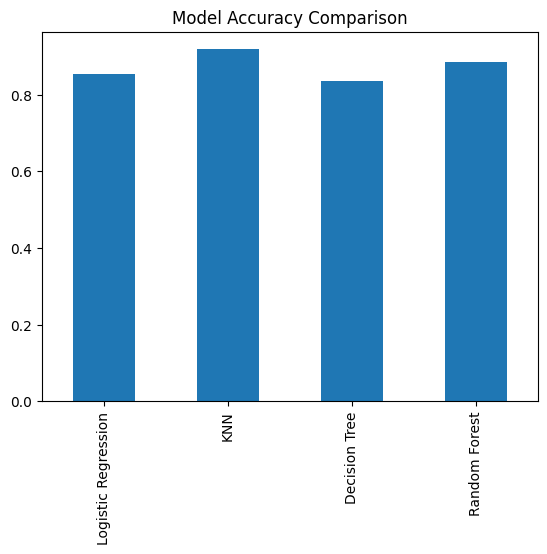

In [1]:
# 🔹 Upload Dataset
from google.colab import files
uploaded = files.upload()

# 🔹 Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 🔹 Load Dataset
df = pd.read_csv('heart.csv')

print("First 5 rows:")
print(df.head())

# 🔹 Features and Target
# Usually target column is 'target'
X = df.drop('target', axis=1)
y = df['target']

# 🔹 Feature Scaling (important for KNN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔹 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔹 Models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

# 🔹 Train + Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cv = cross_val_score(model, X, y, cv=5).mean()

    results[name] = [acc, prec, rec, f1, cv]

    print("\n========================")
    print(name)
    print("========================")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Cross Validation:", cv)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 🔹 Final Comparison Table
result_df = pd.DataFrame(results, index=['Accuracy','Precision','Recall','F1 Score','Cross Val Score'])

print("\nFINAL COMPARISON TABLE:\n")
print(result_df)

# 🔹 Accuracy Graph (for PPT)
import matplotlib.pyplot as plt

result_df.T['Accuracy'].plot(kind='bar')
plt.title("Model Accuracy Comparison")
plt.show()